In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import torch 
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import torch.optim.lr_scheduler as lr_scheduler
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import random
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

In [14]:
#set paths 
#base_dir = "/Users/sofiasuhinin/Desktop/Subglacial_Lakes_Data"
base_dir = r"C:\Users\cambo\Desktop\Subglacial_Lakes_Data"
checkpoint_path_BCE = 'subglacial_lake_cnn.pth' # Best model using the asymmetric focal loss function
checkpoint_path_BW = 'boundary_weighted_model.pth' # Best model using the boundary-weighted loss function
checkpoint_path_AF = 'asymmetric_focal_model.pth' # Best model using the asymmetric focal loss function
lake_location_path = os.path.join(base_dir, "lake_locations.csv")
lake_and_null_path = os.path.join(base_dir, "lake_and_null_loc.csv")
dataset_split_path = os.path.join(base_dir, "dataset_split.csv")
lake_masks = os.path.join(base_dir, "lake_masks")
training_set = os.path.join(base_dir, "lakesTS_2")

In [15]:
###########################
# IMPORT AND PREPARE DATA
###########################

# import data
lake_location = pd.read_csv(lake_location_path)
lake_and_null = pd.read_csv(lake_and_null_path)
dataset_split = pd.read_csv(dataset_split_path)

# list all netcdf files in each folder
tile_files = sorted([f for f in os.listdir(training_set) if f.endswith(".nc")])
mask_files = sorted([f for f in os.listdir(lake_masks) if f.endswith(".nc")])

rows = []

for tile in tile_files:
    
    name = tile.replace(".nc", "")
    
    tile_path = os.path.join(training_set, tile)
    
    mask_file = f"{name}_mask.nc"
    mask_path = os.path.join(lake_masks, mask_file)
    
    if os.path.exists(mask_path):
        has_mask = True
    else:
        mask_path = None
        has_mask = False
    
    rows.append({
        "name": name,
        "tile_path": tile_path,
        "mask_path": mask_path,
        "has_lake": int(has_mask)
    })

dataset_df = pd.DataFrame(rows)

# import class information (train, val, test) based on dataset_split.csv
dataset_split["file_name"] = (
    dataset_split["file"]
    .astype(str)
    .str.strip()
    .str.replace("\\", "/", regex=False)
    .str.split("/")
    .str[-1]
)

# isolate the name of the lake from the file path
dataset_split["name"] = dataset_split["file_name"].str.replace(".nc", "", regex=False)

# merge split with dataset dataframe
dataset_df = dataset_df.merge(
    dataset_split[["name", "dataset"]],
    on="name",
    how="left"
)

# break dataset into 3 categories
train_df = dataset_df[dataset_df["dataset"] == "train"].reset_index(drop=True)
val_df = dataset_df[dataset_df["dataset"] == "val"].reset_index(drop=True)
test_df = dataset_df[dataset_df["dataset"] == "test"].reset_index(drop=True)

#confirm
print("train:", len(train_df))
print("validation:", len(val_df))
print("test:", len(test_df))
print(train_df.head())

class LakeSegmentationDataset(Dataset):
    # define dataset to be used by PyTorch
    def __init__(self, dataframe, tile_var="anomaly", mask_var="lake_mask"):
        self.df = dataframe.reset_index(drop=True)
        self.tile_var = tile_var
        self.mask_var = mask_var

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # load tile
        tile_ds = xr.open_dataset(row["tile_path"])
        arr = tile_ds[self.tile_var].values.astype(np.float32)   # (time, y, x)
        tile_ds.close()

        # collapse time into 2 channels: mean and std
        valid = np.isfinite(arr)
        valid_count = valid.sum(axis=0)

        arr_zeroed = np.where(valid, arr, 0.0)
        mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)

        diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
        std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))

        mean_img[valid_count == 0] = 0.0
        std_img[valid_count == 0] = 0.0

        x = np.stack([mean_img, std_img], axis=0)   # (2, H, W)

        # NORMALIZE USING GLOBAL STATISTICS (pre-computed)
        # calculate global mean and std from training set (done once, then hardcoded here)
        GLOBAL_MEAN_MEAN = -2.4824232087901197 
        GLOBAL_STD_MEAN = 20.268677019954087   
        GLOBAL_STD_STD = 3.7701363263330427   
    
        x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN  # normalize mean channel
        x[1] = x[1] / GLOBAL_STD_STD                         # normalize std channel

        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        # load mask
        if pd.isna(row["mask_path"]) or row["mask_path"] is None:
            mask = np.zeros((x.shape[1], x.shape[2]), dtype=np.float32)
        else:
            mask_ds = xr.open_dataset(row["mask_path"])
            mask = mask_ds[self.mask_var].values.astype(np.float32)   # (y, x)
            mask_ds.close()

        # force binary
        mask = (mask > 0).astype(np.float32)

        # add channel dim
        mask = np.expand_dims(mask, axis=0)   # (1, H, W)

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32)
        )
    
# declare each of the 3 classes (train, val, test) as a dataset
train_dataset = LakeSegmentationDataset(train_df, tile_var="anomaly", mask_var="lake_mask")
val_dataset = LakeSegmentationDataset(val_df, tile_var="anomaly", mask_var="lake_mask")
test_dataset = LakeSegmentationDataset(test_df, tile_var="anomaly", mask_var="lake_mask")

# load datasets using PyTorch DataLoader for batching
train_loader_BCE = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader_BCE = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader_BCE = DataLoader(test_dataset, batch_size=1, shuffle=False)
X_batch, y_batch = next(iter(train_loader_BCE))

train: 73
validation: 16
test: 16
           name                                          tile_path  \
0     Academy45  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...   
1     Academy91  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...   
2       Adams17  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...   
3       Amery22  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...   
4  Beardmore107  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...   

                                           mask_path  has_lake dataset  
0  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...         1   train  
1  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...         1   train  
2  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...         1   train  
3  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...         1   train  
4  C:\Users\cambo\Desktop\Subglacial_Lakes_Data\l...         1   train  


In [16]:
# image convolution
class UNet1(nn.Module):

    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = conv_block(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = conv_block(64, 32)

        self.final = nn.Conv2d(32, out_channels, 1)

    def _match_size(self, src, target):
        """
        Resize src spatial dims to match target spatial dims.
        src: tensor to resize
        target: tensor whose H,W we want
        """
        if src.shape[-2:] != target.shape[-2:]:
            src = F.interpolate(src, size=target.shape[-2:], mode="bilinear", align_corners=False)
        return src

    def forward(self, x):
        e1 = self.enc1(x)                  # [B, 32, 501, 501]
        e2 = self.enc2(self.pool1(e1))     # [B, 64, 250, 250]
        e3 = self.enc3(self.pool2(e2))     # [B, 128, 125, 125]

        b = self.bottleneck(self.pool3(e3))  # [B, 256, 62, 62]

        d3 = self.up3(b)                   # may be [B, 128, 124, 124]
        d3 = self._match_size(d3, e3)      # force to [B, 128, 125, 125]
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = self._match_size(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self._match_size(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = self._match_size(out, x)   # just to be safe
        return out
    
class UNet2(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Dropout2d(0.2),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Dropout2d(0.2)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = conv_block(256, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.final = nn.Conv2d(64, out_channels, 1)

    def _match_size(self, src, target):
        if src.shape[-2:] != target.shape[-2:]:
            src = F.interpolate(src, size=target.shape[-2:], mode="bilinear", align_corners=False)
        return src

    def forward(self, x):
        e1 = self.enc1(x)                  # [B, 64, 256, 256]
        e2 = self.enc2(self.pool1(e1))     # [B, 128, 128, 128]
        e3 = self.enc3(self.pool2(e2))     # [B, 256, 64, 64]
        b = self.bottleneck(self.pool3(e3))  # [B, 512, 32, 32]
        d3 = self.up3(b)
        d3 = self._match_size(d3, e3)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = self._match_size(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = self._match_size(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        out = self.final(d1)
        out = self._match_size(out, x)
        return out

def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [17]:
# ============================================
# PATCH DATASET CLASS
# ============================================
class PatchLakeDataset(Dataset):
    def __init__(self, dataframe, tile_var="anomaly", mask_var="lake_mask", 
                 patch_size=256, stride=128, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.tile_var = tile_var
        self.mask_var = mask_var
        self.patch_size = patch_size
        self.stride = stride
        self.augment = augment
        self.patches = []
        print("Generating patches...")
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            X, _ = self._load_image_mask(row, return_mask=False)
            h, w = X.shape[1], X.shape[2]
            for y in range(0, h - patch_size + 1, stride):
                for x in range(0, w - patch_size + 1, stride):
                    self.patches.append({'idx': idx, 'y': y, 'x': x})
        print(f"Created {len(self.patches)} patches from {len(self.df)} images")

    def _load_image_mask(self, row, return_mask=True):
        tile_path = str(row["tile_path"])
        tile_ds = xr.open_dataset(tile_path, engine='netcdf4')
        arr = tile_ds[self.tile_var].values.astype(np.float32)
        tile_ds.close()
        valid = np.isfinite(arr)
        valid_count = valid.sum(axis=0)
        arr_zeroed = np.where(valid, arr, 0.0)
        mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
        diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
        std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
        mean_img[valid_count == 0] = 0.0
        std_img[valid_count == 0] = 0.0
        x = np.stack([mean_img, std_img], axis=0)
        GLOBAL_MEAN_MEAN = -2.4824232087901197
        GLOBAL_STD_MEAN = 20.268677019954087
        GLOBAL_STD_STD = 3.7701363263330427
        x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN
        x[1] = x[1] / GLOBAL_STD_STD
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        if not return_mask:
            return torch.tensor(x, dtype=torch.float32), None
        if pd.isna(row["mask_path"]) or row["mask_path"] is None:
            mask = np.zeros((x.shape[1], x.shape[2]), dtype=np.float32)
        else:
            mask_path = str(row["mask_path"])
            mask_ds = xr.open_dataset(mask_path, engine='netcdf4')
            mask = mask_ds[self.mask_var].values.astype(np.float32)
            mask_ds.close()
        mask = (mask > 0).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch_info = self.patches[idx]
        X, mask = self._load_image_mask(self.df.iloc[patch_info['idx']])
        y, x = patch_info['y'], patch_info['x']
        ps = self.patch_size
        X_patch = X[:, y:y+ps, x:x+ps]
        mask_patch = mask[:, y:y+ps, x:x+ps]
        if self.augment:
            if random.random() > 0.5:
                X_patch = torch.flip(X_patch, dims=[2])
                mask_patch = torch.flip(mask_patch, dims=[2])
            if random.random() > 0.5:
                X_patch = torch.flip(X_patch, dims=[1])
                mask_patch = torch.flip(mask_patch, dims=[1])
            if random.random() > 0.5:
                k = random.randint(1, 3)
                X_patch = torch.rot90(X_patch, k, dims=[1, 2])
                mask_patch = torch.rot90(mask_patch, k, dims=[1, 2])
        return X_patch, mask_patch

# ============================================
# CREATE DATASETS
# ============================================
patch_size = 256
stride = 128

test_dataset = PatchLakeDataset(test_df, patch_size=patch_size, stride=stride, augment=False)

# ============================================
# CREATE DATALOADERS
# ============================================
test_loader_Patch = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=False)

Generating patches...
Created 64 patches from 16 images


In [18]:
# ============================================
# FULL IMAGE RECONSTRUCTION
# ============================================

def reconstruct_full_image(model, full_image_tensor, patch_size=256, stride=128, device='cuda', threshold=0.5):
    model.eval()
    C, H, W = full_image_tensor.shape
    import math
    n_y = math.ceil((H - patch_size) / stride) + 1
    n_x = math.ceil((W - patch_size) / stride) + 1
    stride_y = stride
    stride_x = stride
    if n_y > 1:
        stride_y = (H - patch_size) / (n_y - 1)
    if n_x > 1:
        stride_x = (W - patch_size) / (n_x - 1)
    prob_accumulator = torch.zeros((H, W)).to(device)
    weight_accumulator = torch.zeros((H, W)).to(device)

    def get_gaussian_weights(patch_size):
        center = patch_size // 2
        y, x = torch.meshgrid(torch.arange(patch_size), torch.arange(patch_size), indexing='ij')
        gaussian = torch.exp(-((x - center)**2 + (y - center)**2) / (2 * (patch_size/4)**2))
        return gaussian / gaussian.max()

    gaussian_weights = get_gaussian_weights(patch_size).to(device)
    print(f"  Reconstructing {H}x{W} image with {n_y}x{n_x} patches...")

    with torch.no_grad():
        for i in range(n_y):
            for j in range(n_x):
                y = min(int(i * stride_y), H - patch_size)
                x = min(int(j * stride_x), W - patch_size)
                patch = full_image_tensor[:, y:y+patch_size, x:x+patch_size].unsqueeze(0).to(device)
                logits = model(patch)
                probs = torch.sigmoid(logits).squeeze().cpu()
                weighted_probs = probs * gaussian_weights.cpu()
                prob_accumulator[y:y+patch_size, x:x+patch_size] += weighted_probs
                weight_accumulator[y:y+patch_size, x:x+patch_size] += gaussian_weights.cpu()

    weight_accumulator = torch.clamp(weight_accumulator, min=1e-8)
    averaged_probs = prob_accumulator / weight_accumulator
    full_pred = (averaged_probs > threshold).float()
    return full_pred.cpu(), averaged_probs.cpu()

def load_full_image(row, device='cuda'):
    tile_path = str(row["tile_path"])
    tile_ds = xr.open_dataset(tile_path, engine='netcdf4')
    arr = tile_ds["anomaly"].values.astype(np.float32)
    tile_ds.close()
    valid = np.isfinite(arr)
    valid_count = valid.sum(axis=0)
    arr_zeroed = np.where(valid, arr, 0.0)
    mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
    diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
    std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
    mean_img[valid_count == 0] = 0.0
    std_img[valid_count == 0] = 0.0
    x = np.stack([mean_img, std_img], axis=0)
    GLOBAL_MEAN_MEAN = -2.4824232087901197
    GLOBAL_STD_MEAN = 20.268677019954087
    GLOBAL_STD_STD = 3.7701363263330427
    x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN
    x[1] = x[1] / GLOBAL_STD_STD
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    if not pd.isna(row["mask_path"]):
        mask_path = str(row["mask_path"])
        mask_ds = xr.open_dataset(mask_path, engine='netcdf4')
        true_mask = mask_ds["lake_mask"].values.astype(np.float32)
        mask_ds.close()
        true_mask = (true_mask > 0).astype(np.float32)
        true_mask = torch.tensor(true_mask)
        has_lake = True
    else:
        true_mask = None
        has_lake = False
    return torch.tensor(x, dtype=torch.float32), true_mask, row['name'], has_lake

def plot_full_reconstruction_simple(sample_idx, model, val_df, val_dataset, device,
                                    patch_size=256, stride=128, threshold=0.5):
    patch_info = val_dataset.patches[sample_idx]
    original_idx = patch_info['idx']
    row = val_df.iloc[original_idx]
    sample_name = row['name']
    print(f"\nReconstructing full image for validation sample index {sample_idx} -> {sample_name}")
    full_image, true_mask, name, has_lake = load_full_image(row, device)
    pred_mask, confidence = reconstruct_full_image(model, full_image, patch_size, stride, device, threshold)

    fig, axes = plt.subplots(1, 5, figsize=(25,6))
    im0 = axes[0].imshow(full_image[0].cpu(), cmap='coolwarm', vmin=-3, vmax=3)
    axes[0].set_title(f'{sample_name} - Mean Anomaly'); axes[0].axis('off'); plt.colorbar(im0, ax=axes[0], fraction=0.046)
    im1 = axes[1].imshow(full_image[1].cpu(), cmap='viridis')
    axes[1].set_title('Std Anomaly'); axes[1].axis('off'); plt.colorbar(im1, ax=axes[1], fraction=0.046)
    if true_mask is not None:
        im2 = axes[2].imshow(true_mask.cpu(), cmap='gray', vmin=0, vmax=1)
        axes[2].set_title('True Mask')
    else:
        blank = np.zeros((full_image.shape[1], full_image.shape[2]))
        im2 = axes[2].imshow(blank, cmap='gray', vmin=0, vmax=1)
        axes[2].set_title('NULL Image')
    axes[2].axis('off'); plt.colorbar(im2, ax=axes[2], fraction=0.046)
    im3 = axes[3].imshow(confidence.cpu(), cmap='hot', vmin=0, vmax=1)
    axes[3].set_title(f'Probability Map\nmax={confidence.max():.3f}'); axes[3].axis('off'); plt.colorbar(im3, ax=axes[3], fraction=0.046)
    im4 = axes[4].imshow(pred_mask.cpu(), cmap='gray', vmin=0, vmax=1)
    lake_pixels = pred_mask.sum().item()
    axes[4].set_title(f'Predicted Mask\n{lake_pixels} lake pixels'); axes[4].axis('off'); plt.colorbar(im4, ax=axes[4], fraction=0.046)
    plt.suptitle(f'Full Reconstruction - {sample_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    if true_mask is not None:
        intersection = (pred_mask * true_mask).sum()
        union = pred_mask.sum() + true_mask.sum()
        dice = (2 * intersection + 1e-6) / (union + 1e-6)
        print(f"  Dice: {dice:.4f}")
    else:
        print(f"  Null image: {'FP' if lake_pixels>0 else 'Correct'}")

In [19]:
# ============================================
# LOAD MODELS
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Recreate the model architecture (must match the saved model)
model_BCE = UNet1(in_channels=2, out_channels=1).to(device)
# Load the saved weights
model_BCE.load_state_dict(torch.load(checkpoint_path_BCE, map_location=device))

# Recreate the model architecture (must match the saved model)
model_BW = UNet2(in_channels=2, out_channels=1).to(device)
# Load the saved weights
model_BW.load_state_dict(torch.load(checkpoint_path_BW, map_location=device))

# Recreate the model architecture (must match the saved model)
model_AF = UNet2(in_channels=2, out_channels=1).to(device)
# Load the saved weights
model_AF.load_state_dict(torch.load(checkpoint_path_AF, map_location=device))

Using device: cpu


<All keys matched successfully>

In [21]:
# ============================================
# DEFINE CALCULATE TEST DICE FUNCTION
# ============================================

@torch.no_grad()
def calculate_test_dice(model, test_loader, device, threshold=0.5):
    """
    Calculate Dice score on the entire test set
    """
    model.eval()
    
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_tn = 0
    n_batches = 0
    
    print(f"\n{'='*60}")
    print(f"CALCULATING DICE SCORE ON TEST SET")
    print(f"{'='*60}")
    
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)
        
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()
        
        # Calculate per-batch metrics
        tp = (preds * y).sum().item()
        fp = (preds * (1 - y)).sum().item()
        fn = ((1 - preds) * y).sum().item()
        tn = ((1 - preds) * (1 - y)).sum().item()
        
        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn
        n_batches += 1
    
    # Calculate final metrics
    total_pixels = total_tp + total_fp + total_fn + total_tn
    lake_pixels = total_tp + total_fn
    bg_pixels = total_tn + total_fp
    
    dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + 1e-6)
    iou = total_tp / (total_tp + total_fp + total_fn + 1e-6)
    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)
    specificity = total_tn / (total_tn + total_fp + 1e-6)
    accuracy = (total_tp + total_tn) / total_pixels
    fpr = total_fp / (total_tn + total_fp + 1e-6)
    
    # Print results
    print(f"\n{'='*60}")
    print("TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"Threshold: {threshold}")
    print(f"\nConfusion Matrix:")
    print(f"                Predicted No    Predicted Lake")
    print(f"Actual No Lake   {total_tn:12,.0f}    {total_fp:12,.0f}")
    print(f"Actual Lake      {total_fn:12,.0f}    {total_tp:12,.0f}")
    print(f"\nTotal pixels: {total_pixels:,.0f}")
    print(f"Lake pixels: {lake_pixels:,.0f} ({100*lake_pixels/total_pixels:.2f}% of data)")
    
    print(f"\n{'='*40}")
    print("METRICS")
    print(f"{'='*40}")
    print(f"Dice Score:      {dice:.4f}")
    print(f"IoU (Jaccard):   {iou:.4f}")
    print(f"Precision:       {precision:.4f}")
    print(f"Recall:          {recall:.4f}")
    print(f"Specificity:     {specificity:.4f}")
    print(f"Accuracy:        {accuracy:.4f}")
    print(f"FPR:             {fpr:.4f}")
    
    return {
        'dice': dice,
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'accuracy': accuracy,
        'fpr': fpr,
        'tp': total_tp,
        'fp': total_fp,
        'fn': total_fn,
        'tn': total_tn
    }


def plot_metrics_matrix(metrics_dict, title="Model Performance Metrics"):
    """
    Create a visually appealing matrix of key metrics
    
    Args:
        metrics_dict: Dictionary with keys 'dice', 'precision', 'recall', 
                     'specificity', 'accuracy', 'iou', 'fpr'
        title: Title for the plot
    """
    # Define metrics to display and their formatting
    metric_configs = [
        {'key': 'dice', 'label': 'Dice Score', 'color': '#2E86AB', 'format': '.3f'},
        {'key': 'iou', 'label': 'IoU (Jaccard)', 'color': '#A23B72', 'format': '.3f'},
        {'key': 'precision', 'label': 'Precision', 'color': '#F18F01', 'format': '.3f'},
        {'key': 'recall', 'label': 'Recall', 'color': '#C73E1D', 'format': '.3f'},
        {'key': 'specificity', 'label': 'Specificity', 'color': '#6A994E', 'format': '.3f'},
        {'key': 'accuracy', 'label': 'Accuracy', 'color': '#5E4B56', 'format': '.3f'},
        {'key': 'fpr', 'label': 'False Pos Rate', 'color': '#9E2A2B', 'format': '.3f'}
    ]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')
    
    # Title
    ax.text(5, 7.5, title, fontsize=18, fontweight='bold', 
            ha='center', va='center', color='#2C3E50')
    
    # Subtitle with threshold info
    if 'threshold' in metrics_dict:
        ax.text(5, 7.0, f"at threshold = {metrics_dict['threshold']:.3f}", 
                fontsize=12, ha='center', va='center', color='#5D6D7E', style='italic')
    
    # Create metric boxes
    box_width = 2.5
    box_height = 1.2
    start_x = 1.5
    start_y = 5.5
    cols = 3
    
    # Add confusion matrix summary if available
    if all(k in metrics_dict for k in ['tp', 'fp', 'fn', 'tn']):
        # Confusion matrix header
        ax.text(7.5, 6.2, 'Confusion Matrix', fontsize=14, fontweight='bold',
                ha='center', va='center', color='#2C3E50')
        
        # Draw confusion matrix
        cm_x, cm_y = 7.5, 5.0
        cell_size = 1.2
        
        # Cell colors
        cmap = LinearSegmentedColormap.from_list('cmap', ['#FFFFFF', '#AED6F1'])
        
        # Create 2x2 grid
        cm_values = [
            [metrics_dict['tn'], metrics_dict['fp']],
            [metrics_dict['fn'], metrics_dict['tp']]
        ]
        
        max_val = max([max(row) for row in cm_values])
        
        for i in range(2):
            for j in range(2):
                x = cm_x + (j-1) * cell_size - cell_size/2
                y = cm_y - (i-0.5) * cell_size
                
                # Cell background
                color_intensity = cm_values[i][j] / max_val
                rect = Rectangle((x - cell_size/2, y - cell_size/2), 
                               cell_size, cell_size,
                               facecolor=cmap(color_intensity),
                               edgecolor='black', linewidth=1)
                ax.add_patch(rect)
                
                # Cell text
                text_color = 'black'  # if color_intensity < 0.5 else 'white'
                ax.text(x, y, f'{cm_values[i][j]:,}', 
                       ha='center', va='center', fontsize=10, fontweight='bold',
                       color=text_color)
        
        # Row and column labels
        ax.text(cm_x - cell_size, cm_y + cell_size/2 + 0.3, 'Actual', 
                ha='center', va='center', fontsize=9, fontweight='bold')
        ax.text(cm_x + cell_size, cm_y - cell_size/2 - 0.3, 'Predicted', 
                ha='center', va='center', fontsize=9, fontweight='bold', rotation=-90)
        
        ax.text(cm_x - cell_size/2, cm_y + cell_size + 0.2, 'No Lake', 
                ha='center', va='center', fontsize=8)
        ax.text(cm_x + cell_size/2, cm_y + cell_size + 0.2, 'Lake', 
                ha='center', va='center', fontsize=8)
        ax.text(cm_x - cell_size - 0.2, cm_y - cell_size/2, 'No Lake', 
                ha='center', va='center', fontsize=8, rotation=90)
        ax.text(cm_x - cell_size - 0.2, cm_y + cell_size/2, 'Lake', 
                ha='center', va='center', fontsize=8, rotation=90)
    
    # Create metric boxes
    for i, config in enumerate(metric_configs):
        if config['key'] not in metrics_dict:
            continue
            
        row = i // cols
        col = i % cols
        
        x = start_x + col * (box_width + 0.5)
        y = start_y - row * (box_height + 0.5)
        
        # Draw box
        rect = Rectangle((x - box_width/2, y - box_height/2), 
                        box_width, box_height,
                        facecolor=config['color'],
                        edgecolor='white', linewidth=2,
                        alpha=0.8, zorder=2)
        ax.add_patch(rect)
        
        # Add shadow effect
        rect_shadow = Rectangle((x - box_width/2 + 0.05, y - box_height/2 - 0.05), 
                               box_width, box_height,
                               facecolor='black', alpha=0.1, zorder=1)
        ax.add_patch(rect_shadow)
        
        # Metric value
        value = metrics_dict[config['key']]
        ax.text(x, y + 0.2, f'{value:{config["format"]}}', 
                ha='center', va='center', fontsize=18, fontweight='bold',
                color='white')
        
        # Metric label
        ax.text(x, y - 0.3, config['label'], 
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white', alpha=0.9)
    
    # Add dataset info if available
    if 'dataset' in metrics_dict:
        ax.text(5, 0.5, f"Dataset: {metrics_dict['dataset']}", 
                fontsize=10, ha='center', va='center', color='#5D6D7E')
    
    plt.tight_layout()
    plt.show()


# ============================================
# NOW RUN THE METRICS MATRIX
# ============================================

print(f"\n{'='*40}")
print("BCE Model")
print(f"{'='*40}")

test_results_BCE = calculate_test_dice(
    model=model_BCE,
    test_loader=test_loader_BCE,
    device=device,
    threshold=0.5  # or your optimal threshold
)

# Add threshold to results
test_results_BCE['threshold'] = 0.5
test_results_BCE['dataset'] = 'Test Set'
print(test_results_BCE)

print(f"\n{'='*40}")
print("Boundary-Weighted Model")
print(f"{'='*40}")

test_results_BW = calculate_test_dice(
    model=model_BW,
    test_loader=test_loader_Patch,
    device=device,
    threshold=0.5  # or your optimal threshold
)

# Add threshold to results
test_results_BW['threshold'] = 0.5
test_results_BW['dataset'] = 'Test Set'
print(test_results_BW)


print(f"\n{'='*40}")
print("Asymmetric Focal Model")
print(f"{'='*40}")

test_results_AF = calculate_test_dice(
    model=model_AF,
    test_loader=test_loader_Patch,
    device=device,
    threshold=0.5  # or your optimal threshold
)

# Add threshold to results
test_results_AF['threshold'] = 0.5
test_results_AF['dataset'] = 'Test Set'
print(test_results_AF)




BCE Model

CALCULATING DICE SCORE ON TEST SET

TEST SET RESULTS
Threshold: 0.5

Confusion Matrix:
                Predicted No    Predicted Lake
Actual No Lake      3,837,934          56,676
Actual Lake            84,987          35,417

Total pixels: 4,015,014
Lake pixels: 120,404 (3.00% of data)

METRICS
Dice Score:      0.3333
IoU (Jaccard):   0.2000
Precision:       0.3846
Recall:          0.2942
Specificity:     0.9854
Accuracy:        0.9647
FPR:             0.0146
{'dice': 0.33334117657974777, 'iou': 0.20000564716399363, 'precision': 0.3845786324651757, 'recall': 0.2941513570953278, 'specificity': 0.9854475801168833, 'accuracy': 0.9647166859194015, 'fpr': 0.014552419882860016, 'tp': 35417.0, 'fp': 56676.0, 'fn': 84987.0, 'tn': 3837934.0, 'threshold': 0.5, 'dataset': 'Test Set'}

Boundary-Weighted Model

CALCULATING DICE SCORE ON TEST SET

TEST SET RESULTS
Threshold: 0.5

Confusion Matrix:
                Predicted No    Predicted Lake
Actual No Lake      3,462,195         537,4

In [22]:
# ============================================
# METRICS BAR GRAPH & TABLE
# ============================================

def plot_model_comparison_bars(data_dict):
    """
    Create grouped bar chart comparing models
    """
    models = list(data_dict.keys())
    metrics = ['Dice', 'Recall', 'Precision', 'Specificity']
    
    x = np.arange(len(metrics))
    width = 0.25
    multiplier = 0
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = ['#4472C4', '#ED7D31', '#70AD47']
    
    for i, (model, values) in enumerate(data_dict.items()):
        offset = width * i
        rects = ax.bar(x + offset, [values[m] for m in metrics], width, 
                       label=model, color=colors[i], edgecolor='black', linewidth=1)
        
        # Add value labels
        for rect, val in zip(rects, [values[m] for m in metrics]):
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width()/2., height + 0.01,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Lake Segmentation Model Comparison', fontsize=18, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics, fontsize=18)
    ax.set_ylim(0, 1.05)
    
    # Legend at top left
    ax.legend(loc='upper left', fontsize=18, framealpha=0.9)
    
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

def print_model_table():
    """Print a clean table with all metrics"""
    
    # Data
    headers = ['Model', 'Dice', 'IoU', 'Precision', 'Recall', 'Specificity', 'Accuracy', 'FPR']
    
    data = [
        ['BCE', 0.333, 0.200, 0.385, 0.294, 0.985, 0.965, 0.015],
        ['Boundary Weighted', 0.189, 0.104, 0.125, 0.393, 0.866, 0.844, 0.134],
        ['Asymmetric Focal', 0.208, 0.116, 0.146, 0.362, 0.897, 0.872, 0.103]
    ]

def plot_simple_table():
    """Create a clean matplotlib table without stars or weird alignment"""
    
    # Data
    columns = ('Model', 'Dice', 'IoU', 'Precision', 'Recall', 'Specificity', 'Accuracy', 'FPR')
    data = [
        ['BCE', 0.333, 0.200, 0.385, 0.294, 0.985, 0.965, 0.015],
        ['Boundary', 0.189, 0.104, 0.125, 0.393, 0.866, 0.844, 0.134],
        ['Asymmetric Focal', 0.208, 0.116, 0.146, 0.362, 0.897, 0.872, 0.103]
    ]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')
    
    # Create table
    table = ax.table(
        cellText=data,
        colLabels=columns,
        cellLoc='center',
        loc='center',
        colColours=['#4472C4'] * len(columns),
        rowColours=['#D9E1F2'] * len(data),
        bbox=[0, 0, 1, 1]
    )
    
    # Style table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Color cells based on column-wise ranking
    for j in range(1, len(columns)):  # For each metric column
        # Extract values for this column
        col_vals = [data[i][j] for i in range(len(data))]
        
        # Determine thresholds based on metric type
        if j == 7:  # FPR column (lower is better)
            sorted_vals = sorted(col_vals)  # ascending
        else:  # All other metrics (higher is better)
            sorted_vals = sorted(col_vals, reverse=True)  # descending
        
        best_val = sorted_vals[0]
        worst_val = sorted_vals[-1]
        
        # Assign colors to each cell in this column
        for i in range(len(data)):
            cell = table[(i+1, j)]
            val = data[i][j]
            
            if val == best_val:
                cell.set_facecolor('#d4edda')  # Green for best
            elif val == worst_val:
                cell.set_facecolor('#f8d7da')  # Red for worst
            else:
                cell.set_facecolor('#fff3cd')  # Yellow for middle
    
    plt.title('Lake Segmentation Model Comparison', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


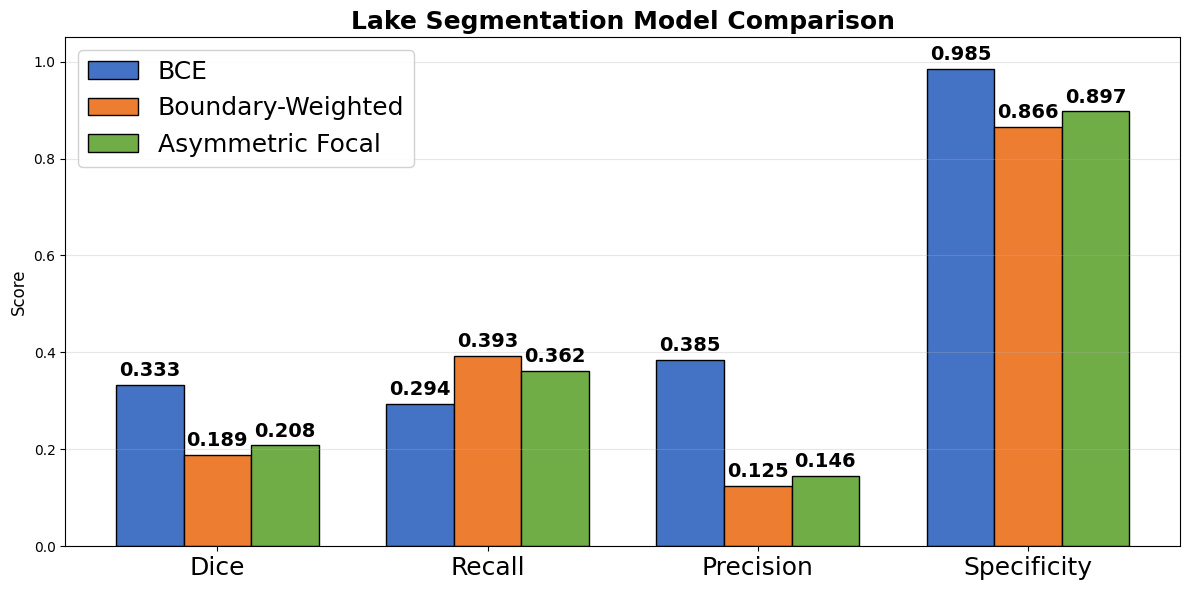

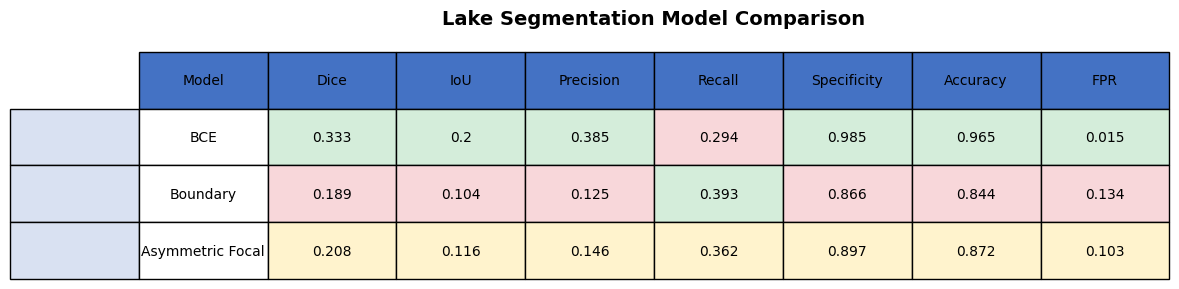

In [23]:
# ============================================
# RUN ALL VISUALIZATIONS
# ============================================

# Data for bar chart - numbers taken from above text output
model_data = {
    'BCE': {'Dice': 0.333, 'Recall': 0.294, 'Precision': 0.385, 'Specificity': 0.985},
    'Boundary-Weighted': {'Dice': 0.189, 'Recall': 0.393, 'Precision': 0.125, 'Specificity': 0.866},
    'Asymmetric Focal': {'Dice': 0.208, 'Recall': 0.362, 'Precision': 0.146, 'Specificity': 0.897}
}

# 1. Bar chart
plot_model_comparison_bars(model_data)
print_model_table()
plot_simple_table()

Found 2 null images in validation set

PLOTTING NULL IMAGE #2
DataFrame index: 15
Image name: null_9


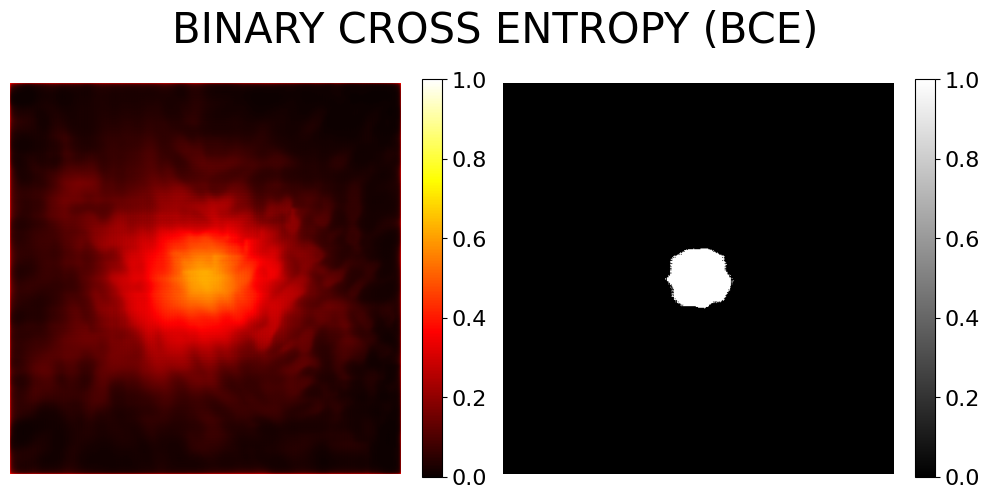

FALSE POSITIVE: Predicted 4873.0 lake pixels in null image
   Max probability: 0.6256
   False positives at: y≈249, x≈251


(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([[0.3984, 0.3311, 0.3109,  ..., 0.2675, 0.3214, 0.4026],
         [0.3263, 0.2197, 0.1965,  ..., 0.1399, 0.2044, 0.3189],
         [0.2904, 0.1873, 0.1507,  ..., 0.1039, 0.1602, 0.2829],
         ...,
         [0.3059, 0.1927, 0.1557,  ..., 0.0600, 0.1026, 0.2325],
         [0.3272, 0.2325, 0.1935,  ..., 0.0957, 0.1415, 0.2654],
         [0.4086, 0.3227, 0.3021,  ..., 0.2033, 0.2654, 0.3618]]))

In [31]:
# ============================================
# PLOT A BCE OUTPUT FOR NULL IMAGE (NO LAKE)
# ============================================

def load_full_image_original(row, device='cuda'):
    """Load and preprocess a full image from dataframe row (no patching)"""
    # Load tile
    tile_path = str(row["tile_path"])
    tile_ds = xr.open_dataset(tile_path, engine='netcdf4')
    arr = tile_ds["anomaly"].values.astype(np.float32)
    tile_ds.close()
    
    # Process to 2-channel (mean, std)
    valid = np.isfinite(arr)
    valid_count = valid.sum(axis=0)
    
    arr_zeroed = np.where(valid, arr, 0.0)
    mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
    
    diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
    std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
    
    mean_img[valid_count == 0] = 0.0
    std_img[valid_count == 0] = 0.0
    
    x = np.stack([mean_img, std_img], axis=0)
    
    # Normalize (same global stats)
    GLOBAL_MEAN_MEAN = -2.4824232087901197 
    GLOBAL_STD_MEAN = 20.268677019954087   
    GLOBAL_STD_STD = 3.7701363263330427   
    
    x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN
    x[1] = x[1] / GLOBAL_STD_STD
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Load true mask if exists
    if not pd.isna(row["mask_path"]):
        mask_path = str(row["mask_path"])
        mask_ds = xr.open_dataset(mask_path, engine='netcdf4')
        true_mask = mask_ds["lake_mask"].values.astype(np.float32)
        mask_ds.close()
        true_mask = (true_mask > 0).astype(np.float32)
        true_mask = torch.tensor(true_mask)
        has_lake = True
    else:
        true_mask = None
        has_lake = False
    
    return torch.tensor(x, dtype=torch.float32), true_mask, row['name'], has_lake


def predict_full_image(model, full_image_tensor, device='cuda', threshold=0.5):
    """
    Run prediction on a full image in one forward pass (no patching)
    """
    model.eval()
    
    with torch.no_grad():
        # Add batch dimension
        input_batch = full_image_tensor.unsqueeze(0).to(device)
        
        # Forward pass
        logits = model(input_batch)
        
        # Get probabilities and predictions
        probs = torch.sigmoid(logits).squeeze().cpu()
        pred = (probs > threshold).float()
    
    return pred.cpu(), probs.cpu()


def plot_full_image_results_original(model, val_df, num_samples=4, device='cuda', threshold=0.5):
    """
    Plot full image results with 5 panels (no patching)
    """
    print("\n" + "="*60)
    print("RECONSTRUCTING FULL VALIDATION IMAGES (NO PATCHING)")
    print("="*60)
    
    # Select samples (mix of lake and null)
    lake_indices = []
    null_indices = []
    
    for idx in range(len(val_df)):
        if pd.isna(val_df.iloc[idx]["mask_path"]):
            null_indices.append(idx)
        else:
            lake_indices.append(idx)
    
    print(f"Found {len(lake_indices)} lake images, {len(null_indices)} null images")
    
    # Choose samples (at least one null if available)
    sample_indices = []
    if null_indices and len(sample_indices) < num_samples:
        sample_indices.append(null_indices[0])
        print(f"Adding null image: {val_df.iloc[null_indices[0]]['name']}")
    
    # Fill rest with lake images
    lake_samples = min(len(lake_indices), num_samples - len(sample_indices))
    if lake_samples > 0:
        sample_indices.extend(lake_indices[:lake_samples])
    
    # Process each image
    for idx in sample_indices:
        row = val_df.iloc[idx]
        print(f"\n--- Processing: {row['name']} ---")
        
        # Load full image
        full_image, true_mask, name, has_lake = load_full_image_original(row, device)
        
        # Predict on full image (one forward pass)
        pred_mask, confidence = predict_full_image(model, full_image, device=device, threshold=threshold)
        
        # Create 5-panel plot
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        
        # 1. Mean anomaly
        im0 = axes[0].imshow(full_image[0].cpu(), cmap='coolwarm', vmin=-3, vmax=3)
        axes[0].set_title(f'{name} - Mean Anomaly', fontsize=12)
        axes[0].axis('off')
        plt.colorbar(im0, ax=axes[0], fraction=0.046)
        
        # 2. Std anomaly
        im1 = axes[1].imshow(full_image[1].cpu(), cmap='viridis')
        axes[1].set_title('Std Anomaly', fontsize=12)
        axes[1].axis('off')
        plt.colorbar(im1, ax=axes[1], fraction=0.046)
        
        # 3. True mask (or null placeholder)
        if true_mask is not None:
            im2 = axes[2].imshow(true_mask.cpu(), cmap='gray', vmin=0, vmax=1)
            axes[2].set_title('True Mask', fontsize=12)
        else:
            blank = np.zeros((full_image.shape[1], full_image.shape[2]))
            im2 = axes[2].imshow(blank, cmap='gray', vmin=0, vmax=1)
            axes[2].set_title('NULL Image (No Lake)', fontsize=12)
        axes[2].axis('off')
        plt.colorbar(im2, ax=axes[2], fraction=0.046)
        
        # 4. Probability map
        im3 = axes[3].imshow(confidence.cpu(), cmap='hot', vmin=0, vmax=1)
        axes[3].set_title(f'Probability Map\nmax={confidence.max():.3f}', fontsize=12)
        axes[3].axis('off')
        plt.colorbar(im3, ax=axes[3], fraction=0.046)
        
        # 5. Predicted mask
        im4 = axes[4].imshow(pred_mask.cpu(), cmap='gray', vmin=0, vmax=1)
        lake_pixels = pred_mask.sum().item()
        axes[4].set_title(f'Predicted Mask\n{lake_pixels} lake pixels', fontsize=12)
        axes[4].axis('off')
        plt.colorbar(im4, ax=axes[4], fraction=0.046)
        
        plt.suptitle(f'Full Image Prediction (No Patching) - {name}', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Calculate Dice if true mask exists
        if true_mask is not None:
            intersection = (pred_mask * true_mask).sum()
            union = pred_mask.sum() + true_mask.sum()
            dice = (2 * intersection + 1e-6) / (union + 1e-6)
            print(f"  Dice Score: {dice:.4f}")
        else:
            print(f"  Null image - checking for false positives...")
            if lake_pixels > 0:
                print(f"FALSE POSITIVE: Predicted {lake_pixels} lake pixels in null image")
            else:
                print(f"Correct: No lakes predicted in null image")

def plot_null_image(model, val_df, null_index, device, threshold=0.5):
    """
    Plot a specific null image from the validation set
    
    Args:
        null_index: which null image to plot (0 = first null, 1 = second null, etc.)
    """
    # Find all null images
    null_indices = []
    for idx in range(len(val_df)):
        if pd.isna(val_df.iloc[idx]["mask_path"]):
            null_indices.append(idx)
    
    print(f"Found {len(null_indices)} null images in validation set")
    
    if null_index >= len(null_indices):
        print(f"Only {len(null_indices)} null images available. Showing last one.")
        null_index = len(null_indices) - 1
    
    # Get the actual dataframe index
    df_idx = null_indices[null_index]
    row = val_df.iloc[df_idx]
    
    print(f"\n{'='*60}")
    print(f"PLOTTING NULL IMAGE #{null_index + 1}")
    print(f"DataFrame index: {df_idx}")
    print(f"Image name: {row['name']}")
    print(f"{'='*60}")
    
    # Load full image
    full_image, true_mask, name, has_lake = load_full_image_original(row, device)
    
    # Predict on full image
    pred_mask, confidence = predict_full_image(model, full_image, device=device, threshold=threshold)
    
    # Create 5-panel plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # 4. Probability map
    im3 = axes[0].imshow(confidence.cpu(), cmap='hot', vmin=0, vmax=1)
    cbar1 = plt.colorbar(im3, ax=axes[0], fraction=0.046)
    cbar1.ax.tick_params(labelsize=16)
    axes[0].axis('off')
    
    # 5. Predicted mask
    im4 = axes[1].imshow(pred_mask.cpu(), cmap='gray', vmin=0, vmax=1)
    cbar2 = plt.colorbar(im4, ax=axes[1], fraction=0.046)
    cbar2.ax.tick_params(labelsize=16)
    lake_pixels = pred_mask.sum().item()
    axes[1].axis('off')
    
    plt.suptitle(f'BINARY CROSS ENTROPY (BCE)', fontsize=30)
    plt.tight_layout()
    plt.show()
    
    # Print false positive info
    if lake_pixels > 0:
        print(f"FALSE POSITIVE: Predicted {lake_pixels} lake pixels in null image")
        print(f"   Max probability: {confidence.max():.4f}")
        
        # Optional: show where the false positives are
        fp_locations = torch.where(pred_mask > 0)
        if len(fp_locations[0]) > 0:
            print(f"   False positives at: y≈{fp_locations[0].float().mean():.0f}, x≈{fp_locations[1].float().mean():.0f}")
    else:
        print(f"Correct: No lakes predicted in null image")
    
    return pred_mask, confidence


# Plot the first null image
plot_null_image(model_BCE, val_df, null_index=1, device=device, threshold=0.5)


RECONSTRUCTING FULL VALIDATION IMAGES
Found 14 lake images, 2 null images
Adding null image: null_4

--- Processing: null_4 ---
  Reconstructing 500x501 image with 3x3 patches...

RECONSTRUCTING FULL VALIDATION IMAGES
Found 14 lake images, 2 null images
Adding null image: null_4

--- Processing: null_4 ---
  Reconstructing 500x501 image with 3x3 patches...


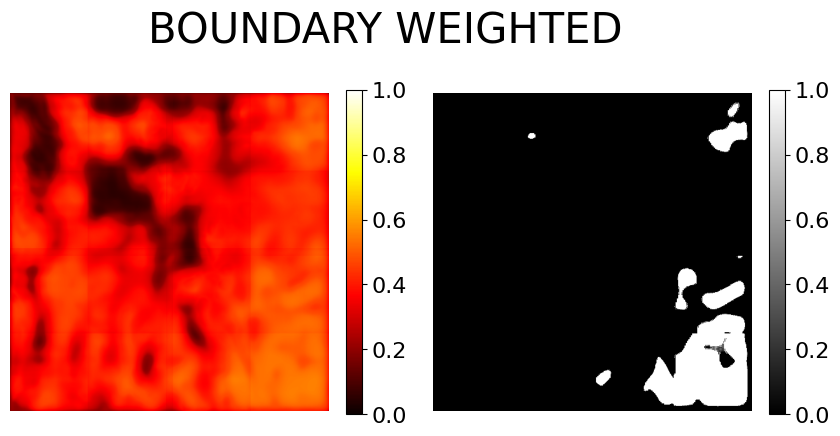

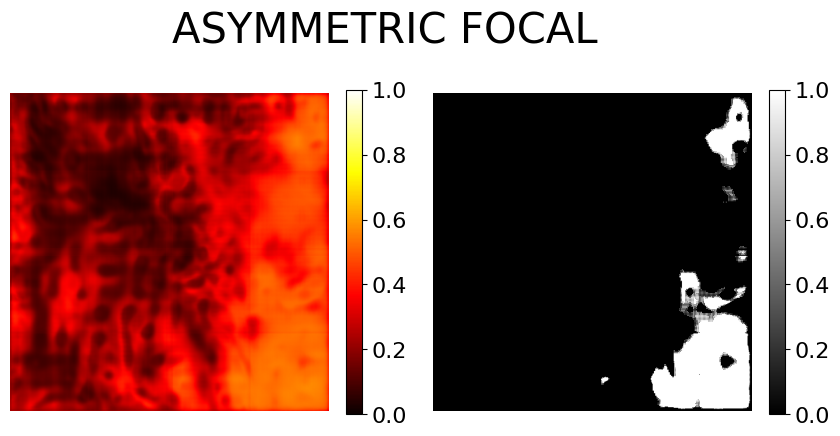

In [39]:
# ============================================
# FULL IMAGE RECONSTRUCTION & PLOTTING 
# ============================================

def reconstruct_full_image(model, full_image_tensor, patch_size=256, stride=128, device='cuda', threshold=0.5):
    """
    Reconstruct full image with forced full coverage (no black bars)
    """
    model.eval()
    C, H, W = full_image_tensor.shape
    
    # Force dimensions to be covered by adjusting stride for last patch
    import math
    n_y = math.ceil((H - patch_size) / stride) + 1
    n_x = math.ceil((W - patch_size) / stride) + 1
    
    # Adjust stride for last patch to ensure coverage
    stride_y = stride
    stride_x = stride
    
    # Calculate actual step sizes to cover whole image
    if n_y > 1:
        stride_y = (H - patch_size) / (n_y - 1)
    if n_x > 1:
        stride_x = (W - patch_size) / (n_x - 1)
    
    # Initialize accumulators
    prob_accumulator = torch.zeros((H, W)).to(device)
    weight_accumulator = torch.zeros((H, W)).to(device)
    
    # Gaussian weights for smooth blending
    def get_gaussian_weights(patch_size):
        center = patch_size // 2
        y, x = torch.meshgrid(torch.arange(patch_size), torch.arange(patch_size), indexing='ij')
        gaussian = torch.exp(-((x - center)**2 + (y - center)**2) / (2 * (patch_size/4)**2))
        return gaussian / gaussian.max()
    
    gaussian_weights = get_gaussian_weights(patch_size).to(device)
    
    print(f"  Reconstructing {H}x{W} image with {n_y}x{n_x} patches...")
    
    with torch.no_grad():
        for i in range(n_y):
            for j in range(n_x):
                # Calculate patch position (ensures full coverage)
                y = min(int(i * stride_y), H - patch_size)
                x = min(int(j * stride_x), W - patch_size)
                
                patch = full_image_tensor[:, y:y+patch_size, x:x+patch_size].unsqueeze(0).to(device)
                logits = model(patch)
                probs = torch.sigmoid(logits).squeeze().cpu()
                
                weighted_probs = probs * gaussian_weights.cpu()
                
                prob_accumulator[y:y+patch_size, x:x+patch_size] += weighted_probs
                weight_accumulator[y:y+patch_size, x:x+patch_size] += gaussian_weights.cpu()
    
    weight_accumulator = torch.clamp(weight_accumulator, min=1e-8)
    averaged_probs = prob_accumulator / weight_accumulator
    full_pred = (averaged_probs > threshold).float()
    
    return full_pred.cpu(), averaged_probs.cpu()


def load_full_image(row, device='cuda'):
    """Load and preprocess a full image from dataframe row"""
    # Load tile
    tile_path = str(row["tile_path"])
    tile_ds = xr.open_dataset(tile_path, engine='netcdf4')
    arr = tile_ds["anomaly"].values.astype(np.float32)
    tile_ds.close()
    
    # Process to 2-channel (mean, std)
    valid = np.isfinite(arr)
    valid_count = valid.sum(axis=0)
    
    arr_zeroed = np.where(valid, arr, 0.0)
    mean_img = arr_zeroed.sum(axis=0) / np.maximum(valid_count, 1)
    
    diff2 = np.where(valid, (arr - mean_img[None, :, :])**2, 0.0)
    std_img = np.sqrt(diff2.sum(axis=0) / np.maximum(valid_count, 1))
    
    mean_img[valid_count == 0] = 0.0
    std_img[valid_count == 0] = 0.0
    
    x = np.stack([mean_img, std_img], axis=0)
    
    # Normalize
    GLOBAL_MEAN_MEAN = -2.4824232087901197 
    GLOBAL_STD_MEAN = 20.268677019954087   
    GLOBAL_STD_STD = 3.7701363263330427   
    
    x[0] = (x[0] - GLOBAL_MEAN_MEAN) / GLOBAL_STD_MEAN
    x[1] = x[1] / GLOBAL_STD_STD
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Load true mask if exists
    if not pd.isna(row["mask_path"]):
        mask_path = str(row["mask_path"])
        mask_ds = xr.open_dataset(mask_path, engine='netcdf4')
        true_mask = mask_ds["lake_mask"].values.astype(np.float32)
        mask_ds.close()
        true_mask = (true_mask > 0).astype(np.float32)
        true_mask = torch.tensor(true_mask)
        has_lake = True
    else:
        true_mask = None
        has_lake = False
    
    return torch.tensor(x, dtype=torch.float32), true_mask, row['name'], has_lake


def plot_full_image_results(model, val_df, num_samples=4, device='cuda', patch_size=256, stride=128, threshold=0.5,modelName=f""):
    """
    Plot full image results with 5 panels, no black bars
    """
    print("\n" + "="*60)
    print("RECONSTRUCTING FULL VALIDATION IMAGES")
    print("="*60)
    
    # Select samples (mix of lake and null)
    lake_indices = []
    null_indices = []
    
    for idx in range(len(val_df)):
        if pd.isna(val_df.iloc[idx]["mask_path"]):
            null_indices.append(idx)
        else:
            lake_indices.append(idx)
    
    print(f"Found {len(lake_indices)} lake images, {len(null_indices)} null images")
    
    # Choose samples (at least one null if available)
    sample_indices = []
    if null_indices and len(sample_indices) < num_samples:
        sample_indices.append(null_indices[0])
        print(f"Adding null image: {val_df.iloc[null_indices[0]]['name']}")
    
    # Fill rest with lake images
    lake_samples = min(len(lake_indices), num_samples - len(sample_indices))
    if lake_samples > 0:
        sample_indices.extend(lake_indices[:lake_samples])
    
    # Reconstruct each image
    for idx in sample_indices:
        row = val_df.iloc[idx]
        print(f"\n--- Processing: {row['name']} ---")
        
        # Load full image
        full_image, true_mask, name, has_lake = load_full_image(row, device)
        
        # Reconstruct (no black bars)
        pred_mask, confidence = reconstruct_full_image(
            model, full_image, patch_size=patch_size, stride=stride, device=device, threshold=threshold
        )
        
        # Create 5-panel plot
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
        
        # 4. Probability map (no black bars!)
        im3 = axes[0].imshow(confidence.cpu(), cmap='hot', vmin=0, vmax=1)
        cbar1 = plt.colorbar(im3, ax=axes[0], fraction=0.046)
        cbar1.ax.tick_params(labelsize=16)
        axes[0].axis('off')
        
        # 5. Predicted mask
        im4 = axes[1].imshow(pred_mask.cpu(), cmap='gray', vmin=0, vmax=1)
        cbar2 = plt.colorbar(im4, ax=axes[1], fraction=0.046)
        cbar2.ax.tick_params(labelsize=16)
        lake_pixels = pred_mask.sum().item()
        axes[1].axis('off')
        
        plt.suptitle(modelName, fontsize=30)
        


# ============================================
# RUN RECONSTRUCTION
# ============================================

plot_full_image_results(
    model=model_BW,
    val_df=val_df,
    num_samples=1,
    device=device,
    patch_size=256,
    stride=128,
    threshold=0.5,
    modelName=f'BOUNDARY WEIGHTED'
)

plot_full_image_results(
    model=model_AF,
    val_df=val_df,
    num_samples=1,
    device=device,
    patch_size=256,
    stride=128,
    threshold=0.5,
    modelName=f'ASYMMETRIC FOCAL'
)